# Advanced Topics — Feature Importance, K-Means, Model Comparison, Data Leakage

*Part of the ML Course Reference Series.*

## Q31: What is Feature Importance and how do you use it?

Tree-based models (Decision Tree, Random Forest) compute **feature importance** — how much each feature contributes to reducing impurity across all splits.

This answers: *which features actually matter?*

Uses:
- Remove unimportant features to simplify the model
- Understand what drives predictions
- Detect data leakage (suspiciously high importance)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
sns.set_theme(style='whitegrid')
np.random.seed(42)
from sklearn.datasets import load_iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
from sklearn.datasets import load_breast_cancer
_cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = _cancer.data, _cancer.target
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression


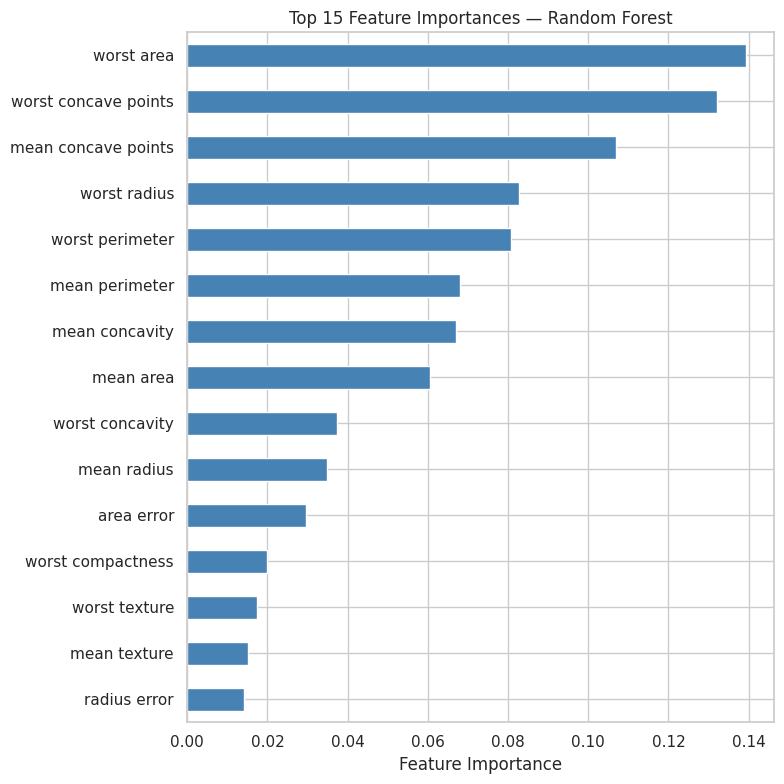

In [2]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_cancer, y_cancer)

importances = pd.Series(rf.feature_importances_, index=X_cancer.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## Q32: What is K-Means clustering?

K-Means partitions data into K clusters by iterating:
1. Assign each point to the nearest centroid
2. Recompute centroids as the mean of assigned points
3. Repeat until centroids stop moving

**Choosing K:** use the **elbow method** — plot inertia (sum of squared distances to nearest centroid) vs K and look for where the decrease flattens.

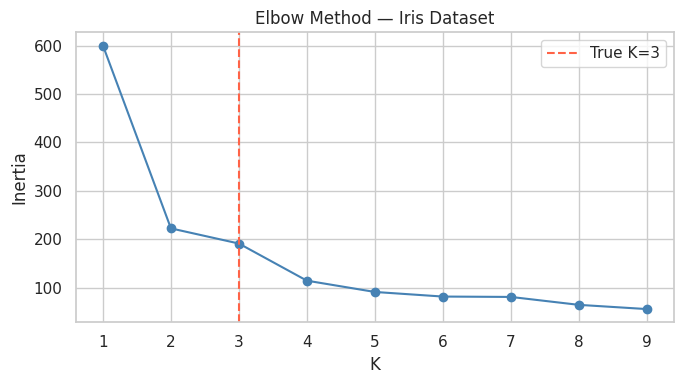

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_iris)

inertias = []
ks = range(1, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o', color='steelblue')
plt.axvline(3, color='tomato', linestyle='--', label='True K=3')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Iris Dataset')
plt.legend()
plt.tight_layout()
plt.show()

## Q33: How do you compare multiple models systematically?

Run the same cross-validation setup on all models and compare mean ± std. Use a held-out test set only once at the very end on the winner.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'KNN (k=7)':          Pipeline([('scl', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=7))]),
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression':Pipeline([('scl', StandardScaler()), ('m', LogisticRegression(max_iter=1000))]),
    'Naive Bayes':        GaussianNB(),
    'SVM (rbf)':          Pipeline([('scl', StandardScaler()), ('m', SVC(kernel='rbf', random_state=42))]),
}

print(f'{"Model":25s}  {"CV Mean":>8}  {"CV Std":>7}')
print('-' * 45)
for name, model in models.items():
    s = cross_val_score(model, X_cancer, y_cancer, cv=5, scoring='accuracy')
    print(f'{name:25s}  {s.mean():.4f}    ±{s.std():.4f}')

Model                       CV Mean   CV Std
---------------------------------------------
KNN (k=7)                  0.9701    ±0.0089
Decision Tree              0.9191    ±0.0180


Random Forest              0.9561    ±0.0228
Logistic Regression        0.9807    ±0.0065


Naive Bayes                0.9385    ±0.0146
SVM (rbf)                  0.9736    ±0.0147


## Q34: What is data leakage and how do you prevent it?

Data leakage happens when information from the test set (or future data) influences training — making model performance look better than it actually is.

**Common sources:**
1. Fitting a scaler on all data before splitting
2. Imputing missing values with statistics from the full dataset
3. Feature engineering using target values
4. Time series: using future data to predict the past

**Prevention: always use a Pipeline.** `cross_val_score(pipeline, ...)` fits preprocessing fresh on each fold's training data.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# WRONG: scale before CV — test fold statistics leak into training
X_leaked = StandardScaler().fit_transform(X_cancer)   # fit on ALL data first
score_leaked = cross_val_score(KNeighborsClassifier(n_neighbors=7),
                               X_leaked, y_cancer, cv=5).mean()

# CORRECT: scaler inside pipeline — fitted only on each fold's train split
pipe = Pipeline([('scl', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7))])
score_correct = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()

print(f'Leaked   CV accuracy: {score_leaked:.4f}')
print(f'Correct  CV accuracy: {score_correct:.4f}')
print('(On large, clean datasets the difference is small but the principle is critical)')

Leaked   CV accuracy: 0.9684
Correct  CV accuracy: 0.9701
(On large, clean datasets the difference is small but the principle is critical)


---
# 10. Feature Engineering